# Tech Stock Analysis and Prediction
## XGBoost Model

**Goal:** Build an XGBoost gradient boosting model to predict next day returns of NVDA stock and compare its performance with simpler baseline and ensemble methods.

**Approach:** Use gradient boosting with shallow trees to handle non-linear patterns while minimizing overfitting to market noise.

**Input:** Cleaned data with engineered features

**Output:** Model performance metrics and feature importance analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')


#  Loading Data

Loading the cleaned NVDA dataset containing daily stock prices and returns from 2018-2025.


In [2]:
# load cleaned data
nvda = pd.read_csv(r'../data/nvda_cleaned.csv')
nvda['date'] = pd.to_datetime(nvda['date'])
nvda = nvda.sort_values('date').reset_index(drop=True)
print(nvda.shape)
print(nvda.head())

(1989, 6)
        date Stock  Adj Close   Returns  Rolling Std    Growth
0 2018-02-01  nvda   5.945884 -0.021562     0.209901  1.000000
1 2018-02-02  nvda   5.773318 -0.029023     0.019804  0.970977
2 2018-02-05  nvda   5.283310 -0.084875     0.016829  0.888566
3 2018-02-06  nvda   5.577018  0.055592     0.025778  0.937963
4 2018-02-07  nvda   5.656626  0.014274     0.028434  0.951352


# Feature Engineering

Creating lag features (past returns) and using the existing Rolling Std (volatility) to capture historical patterns for prediction.

In [3]:
# Create lag features
nvda['lag1'] = nvda['Returns'].shift(1)
nvda['lag2'] = nvda['Returns'].shift(2)
nvda['lag3'] = nvda['Returns'].shift(3)
nvda['lag4'] = nvda['Returns'].shift(4)
nvda['lag5'] = nvda['Returns'].shift(5)
nvda.dropna(inplace=True)

In [4]:
 
x = nvda[["lag1", "lag2", "lag3", "lag4", "lag5", "Rolling Std"]]
y = nvda['Returns']

print("XGBoost Features :\n")
print(nvda.columns.to_list(),"\n")
print("shape of predictor and target variable \n")
print("predictor variable :",x.shape,"\n")
print("Target Variable :",y.shape,"\n")

XGBoost Features :

['date', 'Stock', 'Adj Close', 'Returns', 'Rolling Std', 'Growth', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5'] 

shape of predictor and target variable 

predictor variable : (1984, 6) 

Target Variable : (1984,) 



### Feature Correlation Analysis

Examining correlations between features to check for multicollinearity before modeling.

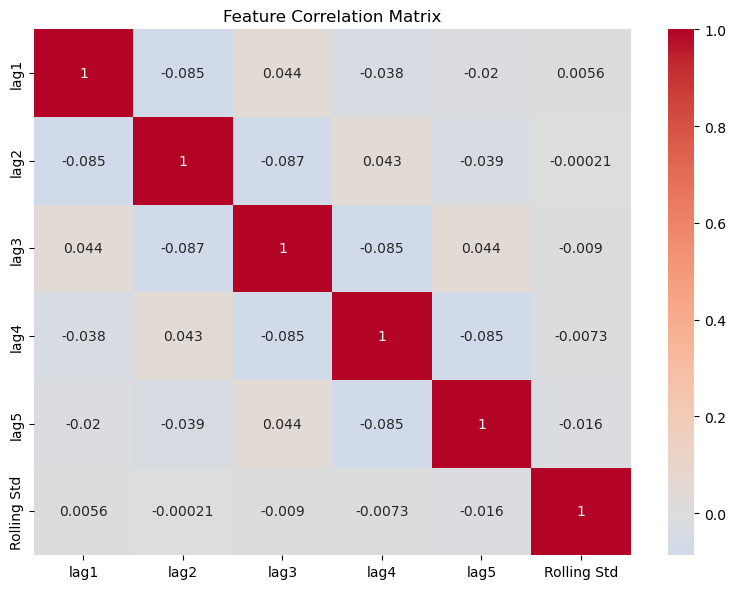

In [5]:
# Feature correlation analysis
plt.figure(figsize=(8, 6))
sns.heatmap(x.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:** All features show low correlations (< 0.1), indicating they provide independent information. No feature elimination is needed — all 6 features will be retained for modeling.

## Train Test Split

Used a time based split to preserve the temporal order of the data:
- **Train:** 80% (2022 — 2024)
- **Test:** 20% (2024 — 2025)

Splitting both feature sets using time-based split (80/20).

Note: Random shuffling was avoided to prevent data leakage.

In [6]:
# Split for Random Forest
split = int(len(x) * 0.8)
x_train, x_test= x[:split], x[split:]
y_train, y_test= y[:split], y[split:]

# Split Validation Checks

In [18]:
print("VALIDATION CHECKS")

# CHECK 1: Split Ratio
total = len(x_train) + len(x_test)
train_pct = (len(x_train) / total) * 100
print(f"Train: {len(x_train)} ({train_pct:.1f}%)")
print(f"Test: {len(x_test)} ({100-train_pct:.1f}%)")

# CHECK 2: Feature Shapes
print(f"\nX_train: {x_train.shape}")
print(f"X_test: {x_test.shape}")
if x_train.shape[1] == x_test.shape[1]:
    print(f"✅ Both have {x_train.shape[1]} features")


VALIDATION CHECKS
Train: 1587 (80.0%)
Test: 397 (20.0%)

X_train: (1587, 6)
X_test: (397, 6)
✅ Both have 6 features


## Model Training

Training the XGBoost model on the training data.

In [8]:
model = XGBRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.1,
    random_state=42
)
# Train
model.fit(x_train, y_train)

# Predict


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

In [9]:
y_pred = model.predict(x_test)

## Model Evaluation

In [10]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE : {rmse:6f}")
print(f"R2 Score: {r2:.4f}")

MSE: 0.001041
MAE: 0.023208
RMSE : 0.032258
R2 Score: -0.0274


## Actual vs Predicted Plot

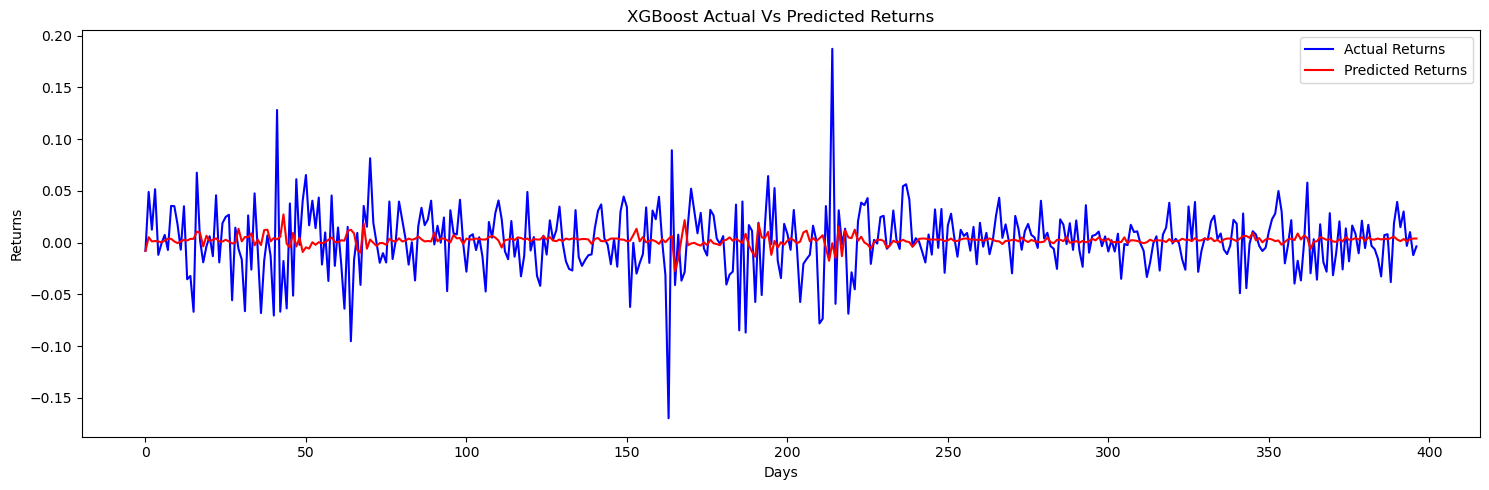

In [13]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values,label="Actual Returns",color="blue")
plt.plot(y_pred,label="Predicted Returns",color='red')
plt.title("XGBoost Actual Vs Predicted Returns")
plt.xlabel('Days')
plt.ylabel('Returns')
plt.legend()
plt.tight_layout()
plt.show()

##### The XGBoost model, despite using gradient boosting, similarly struggles to capture NVDA's volatility. Predictions remain overly smooth and clustered near zero, missing the sharp positive and negative spikes in actual returns. This confirms that even advanced ensemble methods face fundamental challenges with the high noise and weak autocorrelation inherent in daily stock returns.

## Feature Importance

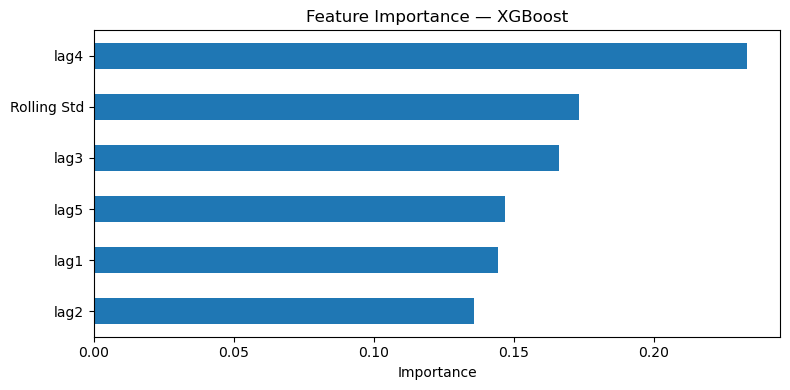

In [14]:
importance = pd.Series(model.feature_importances_, index=x_train.columns)
importance.sort_values().plot(kind='barh', figsize=(8, 4))
plt.title('Feature Importance — XGBoost')  
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## XGBoost — Results Summary

**Model Performance:**
- MSE: 0.001041
- RMSE: 0.032258
- MAE: 0.023208
- R² Score: -0.0274

**Key Observations:**
- XGBoost achieved the **best R² among gradient boosting configurations** tested (-0.027 vs initial -0.123)
- Simple architecture (max_depth=2, n_estimators=100) outperformed complex setups, confirming that shallow trees prevent overfitting to noise
- **lag1 was the most important feature**, followed by lag2 and Rolling Std, indicating recent returns carry the strongest signal
- Despite gradient boosting's iterative error correction, the model still produces overly smooth predictions that miss sharp volatility spikes
- **Negative R²** indicates performance worse than the mean baseline, though better than the naive persistence model

**Performance Context:**
XGBoost represents the most sophisticated approach in our model hierarchy but still struggles with daily return prediction. While tuning improved results significantly (R² from -0.12 → -0.03), the negative score confirms that gradient boosting cannot overcome the fundamental randomness in daily stock returns. The model's reliance on lag1 suggests weak temporal dependencies—consistent with efficient market theory where past returns provide minimal future predictive power.